### Dimensional analysis:
Created 26/02/2026
To assess the importance of drag reduction of spiral patterning on stability, dimensional analysis was used. For a given object of homogeneous material properties, if the drag force $F_d$ is assumed to be producing a torque on the centre of mass, the normal contact force, equal to the weight of the object $G'$, has to act a distance $x$ away from the centre line to produce an opposing torque to balance it. Balancing moments about the centre of mass,

$\tau_d = rF_d = xF_N$

$=> x = \frac{rF_d}{G'} = \frac{r\rho_wC_dAU_0^2}{2f_{calcite}Vg(\rho_{calcite}-\rho_w)}$

which is simply

$x = rW$

where W is the dimensionless ratio of drag and weight.If $x>R$, the radius of the base of the object, the normal contact force moves outside of the object and it will topple over. In other words, if $\frac{x}{R}>1$.

Calculates $\frac{x}{R}$ for a range of $U_0$ and $f_{calcite}$ values (as these are highly uncertain) for the spiral and non-spiral echinoderms.

OLS fit to data:
Fitting a power law to the data:

$y = Ax^B$

First the equation is linearised:

$$
\begin{aligned}
 log(y) &= log(Ax^B) \\
 log(y) &= log(A) + Blog(x) \\
 log(y) &= C + Blog(x)
\end{aligned}
$$
An ordinary least squares regression is performed to find $C$ and $B$. The to plot alongside the original data:
$$
\begin{aligned}
 e^{log(y)} &= e^{(C + Blog(x))} \\
 y &= e^Cx^B
\end{aligned}

In [1]:
# Importing libraries
import matplotlib.pyplot as plt
#import matplotlib as mpl
import numpy as np
import pandas as pd
from statsmodels.formula.api import ols

#from matplotlib import cm
#from matplotlib.ticker import LinearLocator
#from matplotlib.lines import Line2D
#from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import parameters as par


### Analysis of torque using CFD data

In [2]:
def calculate_xR(taxon, Env, f_calcite, Re, flow_through_time, write_interval):
    filename = "../" + taxon.name + "/Re" + str(Re) + "/postProcessing/torque.csv"
    data = pd.read_csv(filename)
    torque = data['avg(Torque (Magnitude))'][int(flow_through_time/write_interval):]
    mean_torque = np.mean(torque)
    G = f_calcite*taxon.V*Env.g*(Env.rho_calcite-Env.rho_w) # Calculate apparent gravity (N)
    x = mean_torque/G
    xR = x/taxon.R
            
    return xR


In [3]:
# Setting up lists of taxa and Re.
taxa = [
    par.Stromatocystites, 
    par.Kailidiscus, 
    par.Helicocystis_straight, 
    par.Helicocystis, 
    par.Gogia_palmeri, 
    par.Gogia_spiralis
]
Re = [100, 500, 1000, 5000, 10000]
f_calcite = 0.2

# Setting up a results dictionary:
results = {taxa[i].name: {} for i in range(len(taxa))}
for i in range(len(taxa)):
    results[taxa[i].name]["Re"] = Re
    results[taxa[i].name]["U_0"] = []
    results[taxa[i].name]["x/R"] = []
    results[taxa[i].name]["error_upper"] = []
    results[taxa[i].name]["error_lower"] = []
    results[taxa[i].name]["fit"] = []

#for i in range(len(taxa)):
#    for j in range(len(Re)):
#        results[taxa[i].name][Re[j]] = {"x/R": [], "error": []}

print(results)

{'stromatocystites': {'Re': [100, 500, 1000, 5000, 10000], 'U_0': [], 'x/R': [], 'error_upper': [], 'error_lower': [], 'fit': []}, 'kailidiscus': {'Re': [100, 500, 1000, 5000, 10000], 'U_0': [], 'x/R': [], 'error_upper': [], 'error_lower': [], 'fit': []}, 'helicocystis_straight': {'Re': [100, 500, 1000, 5000, 10000], 'U_0': [], 'x/R': [], 'error_upper': [], 'error_lower': [], 'fit': []}, 'helicocystis': {'Re': [100, 500, 1000, 5000, 10000], 'U_0': [], 'x/R': [], 'error_upper': [], 'error_lower': [], 'fit': []}, 'gogia_palmeri': {'Re': [100, 500, 1000, 5000, 10000], 'U_0': [], 'x/R': [], 'error_upper': [], 'error_lower': [], 'fit': []}, 'gogia_spiralis': {'Re': [100, 500, 1000, 5000, 10000], 'U_0': [], 'x/R': [], 'error_upper': [], 'error_lower': [], 'fit': []}}


In [4]:
for i in range(len(taxa)):
    for j in range(len(Re)):
        results[taxa[i].name]["U_0"].append(Re[j]*par.Env1.nu/taxa[i].L) # calculate U_0 for each Re
        results[taxa[i].name]["x/R"].append(calculate_xR( # calculate x/R
            taxa[i], 
            par.Env1, 
            f_calcite, 
            Re[j], 
            taxa[i].cfd["Re" + str(Re[j])]['flow_through_time'], 
            taxa[i].cfd["Re" + str(Re[j])]['write_interval']
            ))
        results[taxa[i].name]["error_upper"].append(calculate_xR( # calculate min and max for varing f_calcite
            taxa[i], 
            par.Env1, 
            f_calcite-0.1,
            Re[j], 
            taxa[i].cfd["Re" + str(Re[j])]['flow_through_time'], 
            taxa[i].cfd["Re" + str(Re[j])]['write_interval']
            ))
        results[taxa[i].name]["error_lower"].append(calculate_xR(
            taxa[i], 
            par.Env1, 
            f_calcite+0.1,
            Re[j], 
            taxa[i].cfd["Re" + str(Re[j])]['flow_through_time'], 
            taxa[i].cfd["Re" + str(Re[j])]['write_interval']
            ))
    x = np.log(np.array(results[taxa[i].name]["U_0"]))
    y = np.log(np.array(results[taxa[i].name]["x/R"]))
    model = ols('y ~ x', data={'x': x, 'y': y}).fit()
    #results[taxa[i].name]["fit"].append((model.params.loc['Intercept'], model.params.loc['x']))
    results[taxa[i].name]["fit"].append(model.params)
        

In [5]:
from statsmodels.formula.api import ols

# Setting up a results dictionary:
ols_models = {taxa[i].name: {} for i in range(len(taxa))}
for i in range(len(taxa)):
    x = np.log(np.array(Re))
    y = np.log(np.array(results[taxa[i].name]["x/R"]))
    ols_models[taxa[i].name] = ols('y ~ x', data={'x': x, 'y': y}).fit()


In [6]:
print(results["stromatocystites"]["fit"][0].loc['Intercept'])

2.8727233366751066


(1e-05, 100000.0)

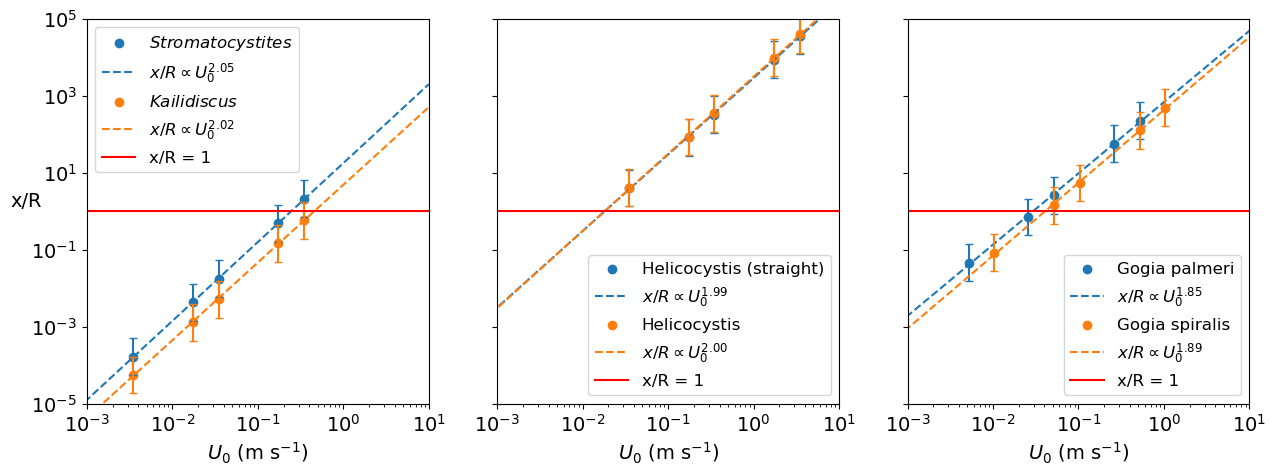

In [7]:
plt.rcParams.update({'font.size': 14})
fig, axs = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

fit_x = np.arange(1E-5, 10, 0.01)
axs[0].scatter(results["stromatocystites"]["U_0"], results["stromatocystites"]["x/R"], marker='o', label=r'$\it{Stromatocystites}$')
axs[0].errorbar(results["stromatocystites"]["U_0"], results["stromatocystites"]["x/R"], yerr=[results["stromatocystites"]["error_lower"], results["stromatocystites"]["error_upper"]], color='tab:blue', fmt='none', capsize=3)
axs[0].plot(fit_x, np.exp(results["stromatocystites"]["fit"][0].loc['Intercept'])*fit_x**results["stromatocystites"]["fit"][0].loc['x'], linestyle='--', label = fr"$x/R \propto U_0^{{ {results['stromatocystites']["fit"][0].loc['x']:.2f} }}$")
axs[0].scatter(results["kailidiscus"]["U_0"], results["kailidiscus"]["x/R"], marker='o', label=r'$\it{Kailidiscus}$')
axs[0].errorbar(results["kailidiscus"]["U_0"], results["kailidiscus"]["x/R"], yerr=[results["kailidiscus"]["error_lower"], results["kailidiscus"]["error_upper"]], color='tab:orange', fmt='none', capsize=3)
axs[0].plot(fit_x, np.exp(results["kailidiscus"]["fit"][0].loc['Intercept'])*fit_x**results["kailidiscus"]["fit"][0].loc['x'], linestyle='--', label = fr"$x/R \propto U_0^{{ {results['kailidiscus']["fit"][0].loc['x']:.2f} }}$")
axs[0].axhline(1, color='red', linestyle='solid', label='x/R = 1')
axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[0].legend(loc='upper left', fontsize=12)
axs[0].set_xlabel(r'$U_0$ (m s$^{-1}$)')
axs[0].set_ylabel('x/R', rotation=0)
axs[0].set_xlim(1E-3, 10)
axs[0].set_ylim(1E-5, 1E5)

axs[1].scatter(results["helicocystis_straight"]["U_0"], results["helicocystis_straight"]["x/R"], marker='o', label='Helicocystis (straight)')
axs[1].errorbar(results["helicocystis_straight"]["U_0"], results["helicocystis_straight"]["x/R"], yerr=[results["helicocystis_straight"]["error_lower"], results["helicocystis_straight"]["error_upper"]], color='tab:blue', fmt='none', capsize=3)
axs[1].plot(fit_x, np.exp(results["helicocystis_straight"]["fit"][0].loc['Intercept'])*fit_x**results["helicocystis_straight"]["fit"][0].loc['x'], linestyle='--', label = fr"$x/R \propto U_0^{{ {results['helicocystis_straight']["fit"][0].loc['x']:.2f} }}$")
axs[1].scatter(results["helicocystis"]["U_0"], results["helicocystis"]["x/R"], marker='o', label='Helicocystis')
axs[1].errorbar(results["helicocystis"]["U_0"], results["helicocystis"]["x/R"], yerr=[results["helicocystis"]["error_lower"], results["helicocystis"]["error_upper"]], color='tab:orange', fmt='none', capsize=3)
axs[1].plot(fit_x, np.exp(results["helicocystis"]["fit"][0].loc['Intercept'])*fit_x**results["helicocystis"]["fit"][0].loc['x'], linestyle='--', label = fr"$x/R \propto U_0^{{ {results['helicocystis']["fit"][0].loc['x']:.2f} }}$")
axs[1].axhline(1, color='red', label='x/R = 1')
axs[1].set_xscale('log')
axs[1].set_yscale('log')
axs[1].legend(loc='lower right', fontsize=12)
axs[1].set_xlabel(r'$U_0$ (m s$^{-1}$)')
axs[1].set_xlim(1E-3, 10)
axs[1].set_ylim(1E-5, 1E5)
#axs[1].set_ylabel('x/R')

axs[2].scatter(results["gogia_palmeri"]["U_0"], results["gogia_palmeri"]["x/R"], marker='o', label='Gogia palmeri')
axs[2].errorbar(results["gogia_palmeri"]["U_0"], results["gogia_palmeri"]["x/R"], yerr=[results["gogia_palmeri"]["error_lower"], results["gogia_palmeri"]["error_upper"]], color='tab:blue', fmt='none', capsize=3)
axs[2].plot(fit_x, np.exp(results["gogia_palmeri"]["fit"][0].loc['Intercept'])*fit_x**results["gogia_palmeri"]["fit"][0].loc['x'], linestyle='--', label = fr"$x/R \propto U_0^{{ {results['gogia_palmeri']["fit"][0].loc['x']:.2f} }}$")   
axs[2].scatter(results["gogia_spiralis"]["U_0"], results["gogia_spiralis"]["x/R"], marker='o', label='Gogia spiralis')
axs[2].errorbar(results["gogia_spiralis"]["U_0"], results["gogia_spiralis"]["x/R"], yerr=[results["gogia_spiralis"]["error_lower"], results["gogia_spiralis"]["error_upper"]], color='tab:orange', fmt='none', capsize=3)
axs[2].plot(fit_x, np.exp(results["gogia_spiralis"]["fit"][0].loc['Intercept'])*fit_x**results["gogia_spiralis"]["fit"][0].loc['x'], linestyle='--', label = fr"$x/R \propto U_0^{{ {results['gogia_spiralis']["fit"][0].loc['x']:.2f} }}$")   
axs[2].axhline(1, color='red', label='x/R = 1')
axs[2].set_xscale('log')
axs[2].set_yscale('log')
axs[2].legend(loc='lower right', fontsize=12)
axs[2].set_xlabel(r'$U_0$ (m s$^{-1}$)')
axs[2].set_xlim(1E-3, 10)
axs[2].set_ylim(1E-5, 1E5)
#axs[2].set_ylabel('x/R')

#plt.savefig('figures/xR.pdf', bbox_inches='tight', dpi=400)


In [8]:
print("Power laws: \n" + "gogia_spiralis: $x/R = " + f"{np.exp(results['gogia_spiralis']['fit'][0].loc['Intercept']):.2f}" + r"U_0^{" + f"{results['gogia_spiralis']['fit'][0].loc['x']:.2f}" + r"}$" + "\n")

Power laws: 
gogia_spiralis: $x/R = 424.19U_0^{1.89}$



Power laws:

| Taxon | Power law ($x/R =$) | $U_0$ for $x/R = 1$ (m s $^{-1}$) |
| -------- | ------- | ------- |
| *Stromatocystites* | $17.69U_0^{2.05}$ | $0.246$
| *Kailidiscus* | $4.83U_0^{2.02}$ | $0.459$
| *Helicocystis* (straight) | $2868.31U_0^{1.99}$ | $0.0183$
| *Helicocystis* | $3111.05U_0^{2.00}$ | 0.0179
| *Gogia palmeri* | $680.66U_0^{1.85}$ | 0.0294
| *Gogia spiralis* | $424.19U_0^{1.89}$ | 0.0407

### Conference figure:

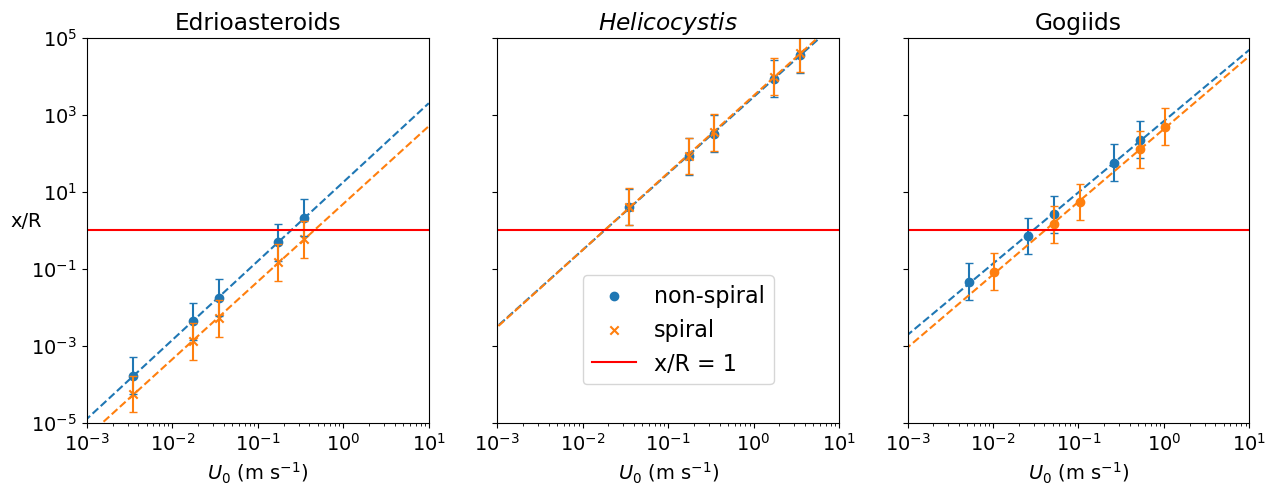

In [9]:
plt.rcParams.update({'font.size': 14})
fig, axs = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

fit_x = np.arange(1E-5, 10, 0.01)
axs[0].scatter(results["stromatocystites"]["U_0"], results["stromatocystites"]["x/R"], marker='o', label=r'$\it{Stromatocystites}$')
axs[0].errorbar(results["stromatocystites"]["U_0"], results["stromatocystites"]["x/R"], yerr=[results["stromatocystites"]["error_lower"], results["stromatocystites"]["error_upper"]], color='tab:blue', fmt='none', capsize=3)
axs[0].plot(fit_x, np.exp(results["stromatocystites"]["fit"][0].loc['Intercept'])*fit_x**results["stromatocystites"]["fit"][0].loc['x'], linestyle='--', label = fr"$x/R \propto U_0^{{ {results['stromatocystites']["fit"][0].loc['x']:.2f} }}$")
axs[0].scatter(results["kailidiscus"]["U_0"], results["kailidiscus"]["x/R"], marker='x', color="C1", label=r'$\it{Kailidiscus}$')
axs[0].errorbar(results["kailidiscus"]["U_0"], results["kailidiscus"]["x/R"], yerr=[results["kailidiscus"]["error_lower"], results["kailidiscus"]["error_upper"]], color='C1', fmt='none', capsize=3)
axs[0].plot(fit_x, np.exp(results["kailidiscus"]["fit"][0].loc['Intercept'])*fit_x**results["kailidiscus"]["fit"][0].loc['x'], linestyle='--', label = fr"$x/R \propto U_0^{{ {results['kailidiscus']["fit"][0].loc['x']:.2f} }}$")
axs[0].axhline(1, color='red', linestyle='solid', label='x/R = 1')
axs[0].set_xscale('log')
axs[0].set_yscale('log')
#axs[0].legend(loc='upper left', fontsize=12)
axs[0].set_xlabel(r'$U_0$ (m s$^{-1}$)')
axs[0].set_ylabel('x/R', rotation=0)
axs[0].set_xlim(1E-3, 10)
axs[0].set_ylim(1E-5, 1E5)
axs[0].set_title('Edrioasteroids')

axs[1].scatter(results["helicocystis_straight"]["U_0"], results["helicocystis_straight"]["x/R"], marker='o', label='non-spiral')
axs[1].errorbar(results["helicocystis_straight"]["U_0"], results["helicocystis_straight"]["x/R"], yerr=[results["helicocystis_straight"]["error_lower"], results["helicocystis_straight"]["error_upper"]], color='tab:blue', fmt='none', capsize=3)
axs[1].plot(fit_x, np.exp(results["helicocystis_straight"]["fit"][0].loc['Intercept'])*fit_x**results["helicocystis_straight"]["fit"][0].loc['x'], linestyle='--')
axs[1].scatter(results["helicocystis"]["U_0"], results["helicocystis"]["x/R"], marker='x', color='C1', label='spiral')
axs[1].errorbar(results["helicocystis"]["U_0"], results["helicocystis"]["x/R"], yerr=[results["helicocystis"]["error_lower"], results["helicocystis"]["error_upper"]], color='C1', fmt='none', capsize=3)
axs[1].plot(fit_x, np.exp(results["helicocystis"]["fit"][0].loc['Intercept'])*fit_x**results["helicocystis"]["fit"][0].loc['x'], linestyle='--')
axs[1].axhline(1, color='red', label='x/R = 1')
axs[1].set_xscale('log')
axs[1].set_yscale('log')
axs[1].legend(loc=[0.25,0.1], fontsize=16)
axs[1].set_xlabel(r'$U_0$ (m s$^{-1}$)')
axs[1].set_xlim(1E-3, 10)
axs[1].set_ylim(1E-5, 1E5)
axs[1].set_title(r'$\it{Helicocystis}$')

axs[2].scatter(results["gogia_palmeri"]["U_0"], results["gogia_palmeri"]["x/R"], marker='o', label='Gogia palmeri')
axs[2].errorbar(results["gogia_palmeri"]["U_0"], results["gogia_palmeri"]["x/R"], yerr=[results["gogia_palmeri"]["error_lower"], results["gogia_palmeri"]["error_upper"]], color='tab:blue', fmt='none', capsize=3)
axs[2].plot(fit_x, np.exp(results["gogia_palmeri"]["fit"][0].loc['Intercept'])*fit_x**results["gogia_palmeri"]["fit"][0].loc['x'], linestyle='--', label = fr"$x/R \propto U_0^{{ {results['gogia_palmeri']["fit"][0].loc['x']:.2f} }}$")   
axs[2].scatter(results["gogia_spiralis"]["U_0"], results["gogia_spiralis"]["x/R"], marker='o', color='C1', label='Gogia spiralis')
axs[2].errorbar(results["gogia_spiralis"]["U_0"], results["gogia_spiralis"]["x/R"], yerr=[results["gogia_spiralis"]["error_lower"], results["gogia_spiralis"]["error_upper"]], color='C1', fmt='none', capsize=3)
axs[2].plot(fit_x, np.exp(results["gogia_spiralis"]["fit"][0].loc['Intercept'])*fit_x**results["gogia_spiralis"]["fit"][0].loc['x'], linestyle='--', label = fr"$x/R \propto U_0^{{ {results['gogia_spiralis']["fit"][0].loc['x']:.2f} }}$")   
axs[2].axhline(1, color='red', label='x/R = 1')
axs[2].set_xscale('log')
axs[2].set_yscale('log')
#axs[2].legend(loc='lower right', fontsize=12)
axs[2].set_xlabel(r'$U_0$ (m s$^{-1}$)')
axs[2].set_xlim(1E-3, 10)
axs[2].set_ylim(1E-5, 1E5)
axs[2].set_title('Gogiids')

plt.savefig('figures/xR_conference.png', bbox_inches='tight', dpi=400)